In [2]:
#!pip install tensorflow opencv-python seaborn scikit-learn

In [3]:
import os
import cv2
import shutil
import random
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from google.colab import files,drive
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
print("TensorFlow Version :", tf.__version__)

TensorFlow Version : 2.20.0


In [4]:
print("GPU Available :", tf.config.list_physical_devices('GPU'))

GPU Available : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [5]:
dataset_path = "/kaggle/input/datasets/ankithgj/dataset-note/Currency_Dataset"

In [6]:
import os

print(os.listdir(dataset_path))

['Real_500', 'Fake_2000', 'Real_2000', 'Fake_500']


In [7]:
IMG_SIZE = (128,128)
BATCH_SIZE = 32
SEED = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 4042 files belonging to 4 classes.
Using 3234 files for training.


I0000 00:00:1785919714.565953      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Found 4042 files belonging to 4 classes.
Using 808 files for validation.


In [8]:
class_names = train_ds.class_names
print(class_names)

['Fake_2000', 'Fake_500', 'Real_2000', 'Real_500']


Displaying of Images

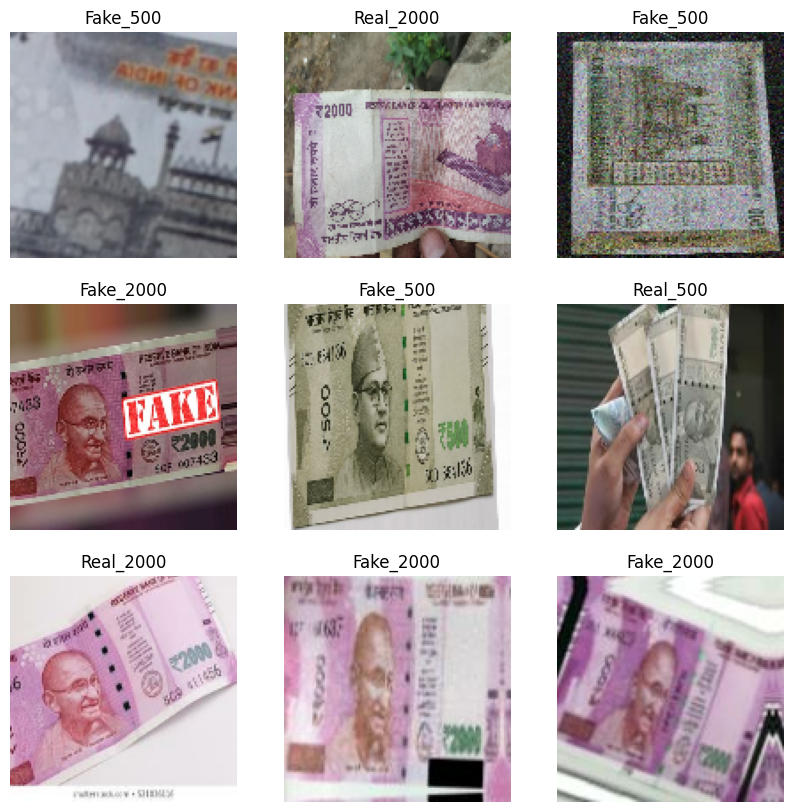

In [9]:
plt.figure(figsize=(10,10))

for images, labels in train_ds.take(1):
    for i in range(9):
        plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")
plt.show()

In [10]:
print("Classes:", train_ds.class_names)

for folder in os.listdir(dataset_path):
    path = os.path.join(dataset_path, folder)
    if os.path.isdir(path):
        print(folder, ":", len(os.listdir(path)))

Classes: ['Fake_2000', 'Fake_500', 'Real_2000', 'Real_500']
Real_500 : 1099
Fake_2000 : 923
Real_2000 : 1014
Fake_500 : 1009


In [11]:
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D,MaxPooling2D,BatchNormalization,Dropout,GlobalAveragePooling2D,Dense
from tensorflow.keras.callbacks import EarlyStopping,ReduceLROnPlateau,ModelCheckpoint

Building CNN model

In [12]:
def create_model(input_shape, num_classes):

    model = Sequential()

    # First Convolution Block
    model.add(Conv2D(32, (3,3), activation='relu', input_shape=input_shape))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2,2)))

    # Second Convolution Block
    model.add(Conv2D(64, (3,3), activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2,2)))

    # Third Convolution Block
    model.add(Conv2D(128, (3,3), activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2,2)))

    # Fourth Convolution Block
    model.add(Conv2D(256, (3,3), activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2,2)))

    # Fully Connected Layer
    model.add(GlobalAveragePooling2D())

    model.add(Dense(256, activation='relu'))
    model.add(Dropout(0.5))

    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.3))

    # Output Layer
    model.add(Dense(num_classes, activation='softmax'))

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [13]:
input_shape = (128,128,3)
num_classes = len(train_ds.class_names)
model = create_model(input_shape, num_classes)
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 126, 126, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 61, 61, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 489,540 (1.87 MB)

 Trainable params: 488,580 (1.86 MB)

 Non-trainable params: 960 (3.75 KB)

In [14]:
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=4,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    'Currency_CNN.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_accuracy',
    factor=0.2,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

Train the Model

In [15]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    callbacks=[early_stop, checkpoint, reduce_lr]
)

Epoch 1/25
  1/102 ━━━━━━━━━━━━━━━━━━━━ 16:28 10s/step - accuracy: 0.2500 - loss: 1.8154

I0000 00:00:1785919728.219408     136 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


  6/102 ━━━━━━━━━━━━━━━━━━━━ 12s 132ms/step - accuracy: 0.3566 - loss: 1.4873

Corrupt JPEG data: premature end of data segment


 33/102 ━━━━━━━━━━━━━━━━━━━━ 15s 228ms/step - accuracy: 0.5091 - loss: 1.1723

...

 92/102 ━━━━━━━━━━━━━━━━━━━━ 1s 190ms/step - accuracy: 0.9720 - loss: 0.0753

Corrupt JPEG data: premature end of data segment


101/102 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step - accuracy: 0.9714 - loss: 0.0767

Corrupt JPEG data: premature end of data segment



Epoch 25: val_accuracy improved from 0.93936 to 0.94059, saving model to Currency_CNN.keras

Epoch 25: finished saving model to Currency_CNN.keras
102/102 ━━━━━━━━━━━━━━━━━━━━ 24s 232ms/step - accuracy: 0.9644 - loss: 0.0918 - val_accuracy: 0.9406 - val_loss: 0.1987 - learning_rate: 2.0000e-04


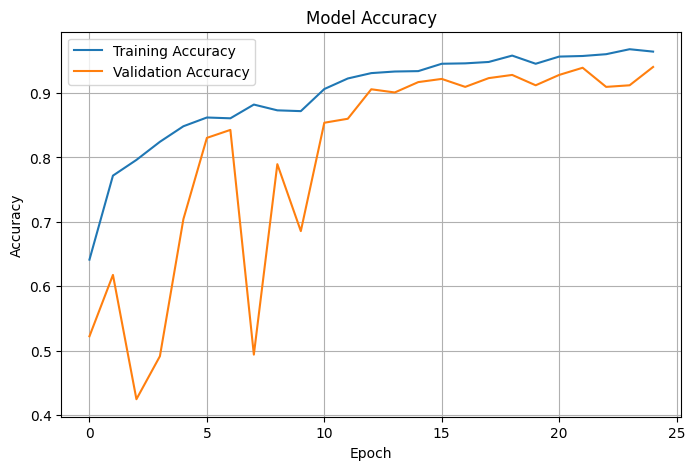

In [16]:
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

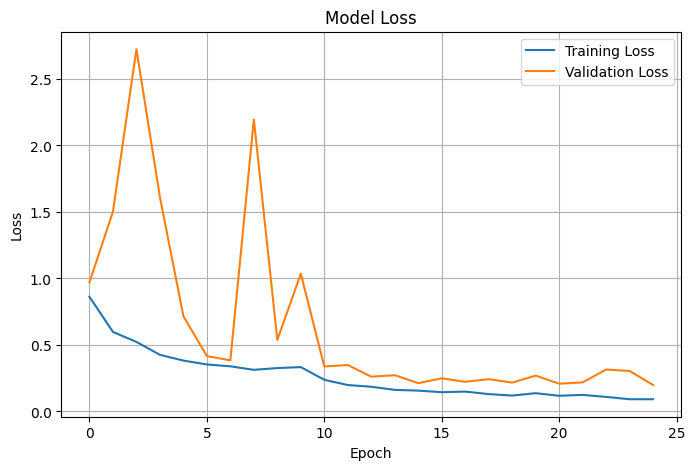

In [17]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

Corrupt JPEG data: premature end of data segment


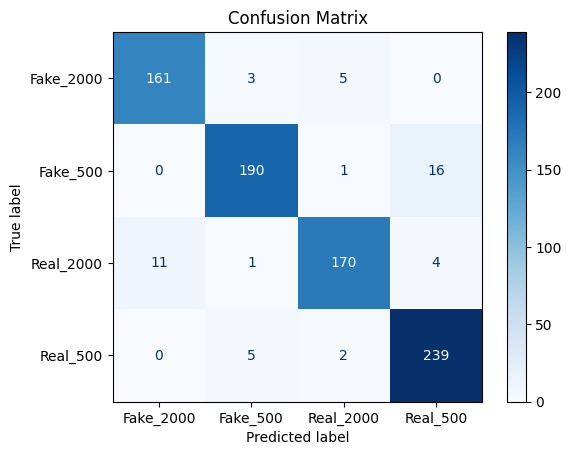

In [18]:
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay,classification_report

y_true = []
y_pred = []

for images, labels in val_ds:
    predictions = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=train_ds.class_names
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

In [19]:
print(classification_report(
    y_true,
    y_pred,
    target_names=train_ds.class_names
))

              precision    recall  f1-score   support

   Fake_2000       0.94      0.95      0.94       169
    Fake_500       0.95      0.92      0.94       207
   Real_2000       0.96      0.91      0.93       186
    Real_500       0.92      0.97      0.95       246

    accuracy                           0.94       808
   macro avg       0.94      0.94      0.94       808
weighted avg       0.94      0.94      0.94       808



In [20]:
loss, accuracy = model.evaluate(val_ds)

print(f"Validation Accuracy : {accuracy*100:.2f}%")
print(f"Validation Loss : {loss:.4f}")

19/26 ━━━━━━━━━━━━━━━━━━━━ 1s 195ms/step - accuracy: 0.9454 - loss: 0.2343

Corrupt JPEG data: premature end of data segment


26/26 ━━━━━━━━━━━━━━━━━━━━ 5s 180ms/step - accuracy: 0.9406 - loss: 0.1987
Validation Accuracy : 94.06%
Validation Loss : 0.1987
